<a href="https://colab.research.google.com/github/hamnasz/DevByte/blob/main/Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering & PCA
**DevByte AI/ML Internship — BETA Project**

**Assigned:** 2026-06-30 &nbsp;|&nbsp; **Due:** 2026-08-04

### What this notebook does
Takes a raw house dataset with both numeric and categorical columns, applies proper feature engineering, then uses PCA to compress the feature space while keeping most of the information.

### Pipeline at a glance
| Step | Task |
|---|---|
| 1 | Setup & imports |
| 2 | Dataset generation |
| 3 | Exploratory Data Analysis |
| 4 | One-Hot Encoding (categorical features) |
| 5 | Standard Scaling + MinMax comparison |
| 6 | Full preprocessing pipeline |
| 7 | PCA — explained variance & scree plot |
| 8 | PCA — 2D and 3D visualizations |
| 9 | PCA — biplot (feature loading vectors) |
| 10 | Choosing optimal number of components |
| 11 | Before vs After PCA — classifier comparison |
| 12 | Summary |

---
## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# For 3D plot
from mpl_toolkits.mplot3d import Axes3D

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
SEED         = 42
CLASS_NAMES  = ['Budget', 'Mid-Range', 'Premium']
CLASS_COLORS = ['#4C72B0', '#55A868', '#C44E52']

print('All libraries loaded.')

All libraries loaded.


---
## Step 2: Generate the Dataset

This version of the housing dataset adds **three categorical columns** on top of the nine numeric ones from previous tasks, so we have something meaningful to one-hot encode.

| Column | Type | Values |
|---|---|---|
| region | Categorical | Urban, Suburban, Rural |
| property_type | Categorical | Apartment, House, Villa, Condo |
| condition | Categorical | Poor, Fair, Good, Excellent |

In [2]:
np.random.seed(SEED)
n = 1200

# ---- Numeric features ----
area_sqft          = np.random.randint(400,  6001, n)
num_bedrooms       = np.random.randint(1,    7,    n)
num_bathrooms      = np.clip(num_bedrooms - np.random.randint(0, 2, n), 1, 5)
age_years          = np.random.randint(0,    41,   n)
distance_km        = np.round(np.random.uniform(0.5, 25.0, n), 1)
has_garden         = np.random.choice([0, 1], n, p=[0.45, 0.55])
has_parking        = np.random.choice([0, 1], n, p=[0.30, 0.70])
neighborhood_score = np.round(np.random.uniform(1.0, 10.0, n), 1)
floor_number       = np.random.randint(0, 11, n)

# ---- Categorical features ----
region_map  = {0: 'Urban', 1: 'Suburban', 2: 'Rural'}
type_map    = {0: 'Apartment', 1: 'House', 2: 'Villa', 3: 'Condo'}
cond_map    = {0: 'Poor', 1: 'Fair', 2: 'Good', 3: 'Excellent'}

region        = np.vectorize(region_map.get)(np.random.choice([0,1,2], n, p=[0.5,0.3,0.2]))
property_type = np.vectorize(type_map.get)(np.random.choice([0,1,2,3], n, p=[0.35,0.30,0.15,0.20]))
condition     = np.vectorize(cond_map.get)(np.random.choice([0,1,2,3], n, p=[0.10,0.25,0.40,0.25]))

# ---- Target price & class ----
region_bonus    = {'Urban': 15, 'Suburban': 5,  'Rural': -5}
type_bonus      = {'Villa': 40, 'House': 10,    'Condo': 0,    'Apartment': -10}
condition_bonus = {'Excellent': 20, 'Good': 8,  'Fair': -5,    'Poor': -20}

noise = np.random.normal(0, 10, n)
price = (
      0.030  * area_sqft
    + 8.0    * num_bedrooms
    + 5.0    * num_bathrooms
    - 0.8    * age_years
    - 2.5    * distance_km
    + 10.0   * has_garden
    + 7.0    * has_parking
    + 6.0    * neighborhood_score
    - 0.5    * floor_number
    + np.array([region_bonus[r]    for r in region])
    + np.array([type_bonus[t]      for t in property_type])
    + np.array([condition_bonus[c] for c in condition])
    + noise
)
price = np.clip(price, 15, 700)

t1, t2 = np.percentile(price, [33.3, 66.6])
target = np.where(price < t1, 0, np.where(price < t2, 1, 2))

df = pd.DataFrame({
    'area_sqft'          : area_sqft,
    'num_bedrooms'       : num_bedrooms,
    'num_bathrooms'      : num_bathrooms,
    'age_years'          : age_years,
    'distance_km'        : distance_km,
    'has_garden'         : has_garden,
    'has_parking'        : has_parking,
    'neighborhood_score' : neighborhood_score,
    'floor_number'       : floor_number,
    'region'             : region,
    'property_type'      : property_type,
    'condition'          : condition,
    'property_class'     : target
})

NUM_COLS = ['area_sqft','num_bedrooms','num_bathrooms','age_years',
            'distance_km','has_garden','has_parking','neighborhood_score','floor_number']
CAT_COLS = ['region', 'property_type', 'condition']
TARGET   = 'property_class'

print(f'Dataset shape : {df.shape}')
print(f'Numeric cols  : {len(NUM_COLS)}')
print(f'Categorical   : {CAT_COLS}')
print(f'Class balance :')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:10s}: {(target==i).sum()}')
df.head(6)

Dataset shape : (1200, 13)
Numeric cols  : 9
Categorical   : ['region', 'property_type', 'condition']
Class balance :
  Budget    : 400
  Mid-Range : 399
  Premium   : 401


,area_sqft,num_bedrooms,num_bathrooms,age_years,distance_km,has_garden,has_parking,neighborhood_score,floor_number,region,property_type,condition,property_class
0,1260,5,5,39,2.4,1,1,1.9,8,Urban,Condo,Good,1
1,5790,3,3,11,20.8,1,0,6.2,1,Urban,Condo,Poor,2
2,5626,2,1,11,9.0,1,1,6.7,9,Urban,House,Poor,2
3,5591,2,1,14,13.3,0,1,4.3,10,Urban,House,Good,2
4,4172,3,3,40,20.0,0,0,5.8,0,Suburban,Villa,Fair,1
5,3492,6,5,18,22.2,1,0,8.1,9,Urban,Apartment,Good,2


---
## Step 3: Exploratory Data Analysis

In [3]:
print(df.describe().round(2))
print('\nMissing values per column:')
print(df.isnull().sum())

       area_sqft  num_bedrooms  num_bathrooms  age_years  distance_km  \
count    1200.00       1200.00        1200.00    1200.00      1200.00   
mean     3288.28          3.48           2.97      20.29        12.74   
std      1591.83          1.71           1.54      11.93         7.04   
min       403.00          1.00           1.00       0.00         0.50   
25%      1979.25          2.00           1.00      10.00         6.70   
50%      3307.50          3.00           3.00      20.00        12.80   
75%      4644.50          5.00           4.00      31.00        18.92   
max      6000.00          6.00           5.00      40.00        24.90   

       has_garden  has_parking  neighborhood_score  floor_number  \
count     1200.00      1200.00             1200.00       1200.00   
mean         0.54         0.68                5.61          5.15   
std          0.50         0.47                2.60          3.11   
min          0.00         0.00                1.00          0.00   
25

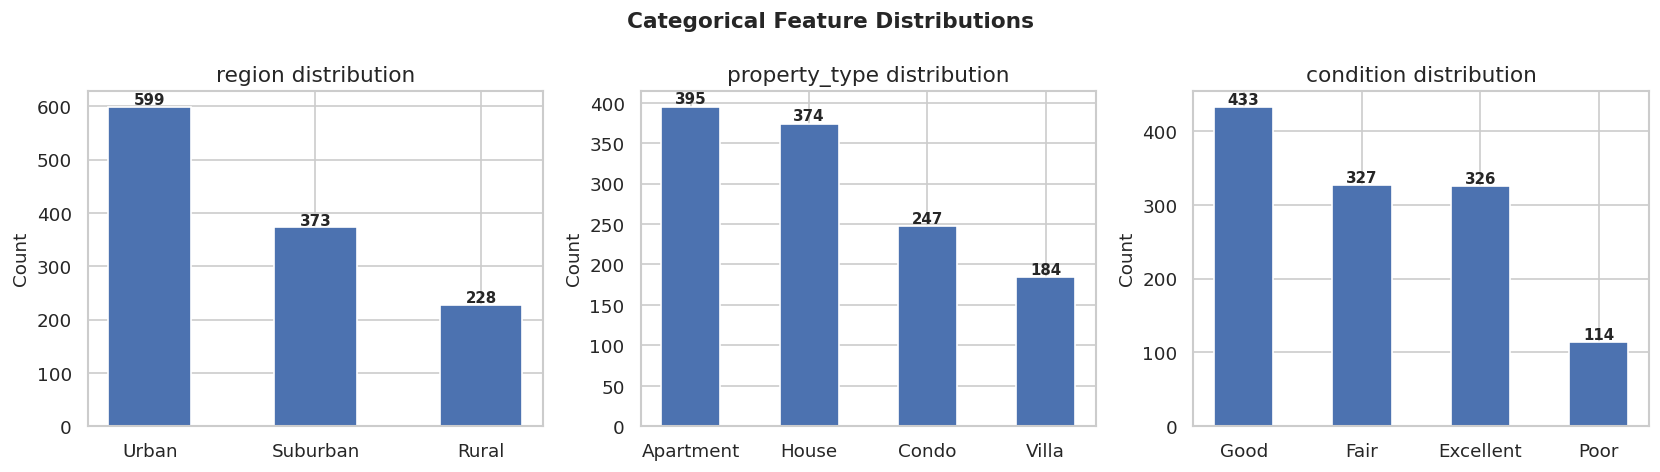

In [4]:
# Categorical column value counts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, CAT_COLS):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='#4C72B0', edgecolor='white', width=0.5)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 4, str(v), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{col} distribution')
    ax.set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_cat_dist.png', bbox_inches='tight')
plt.show()

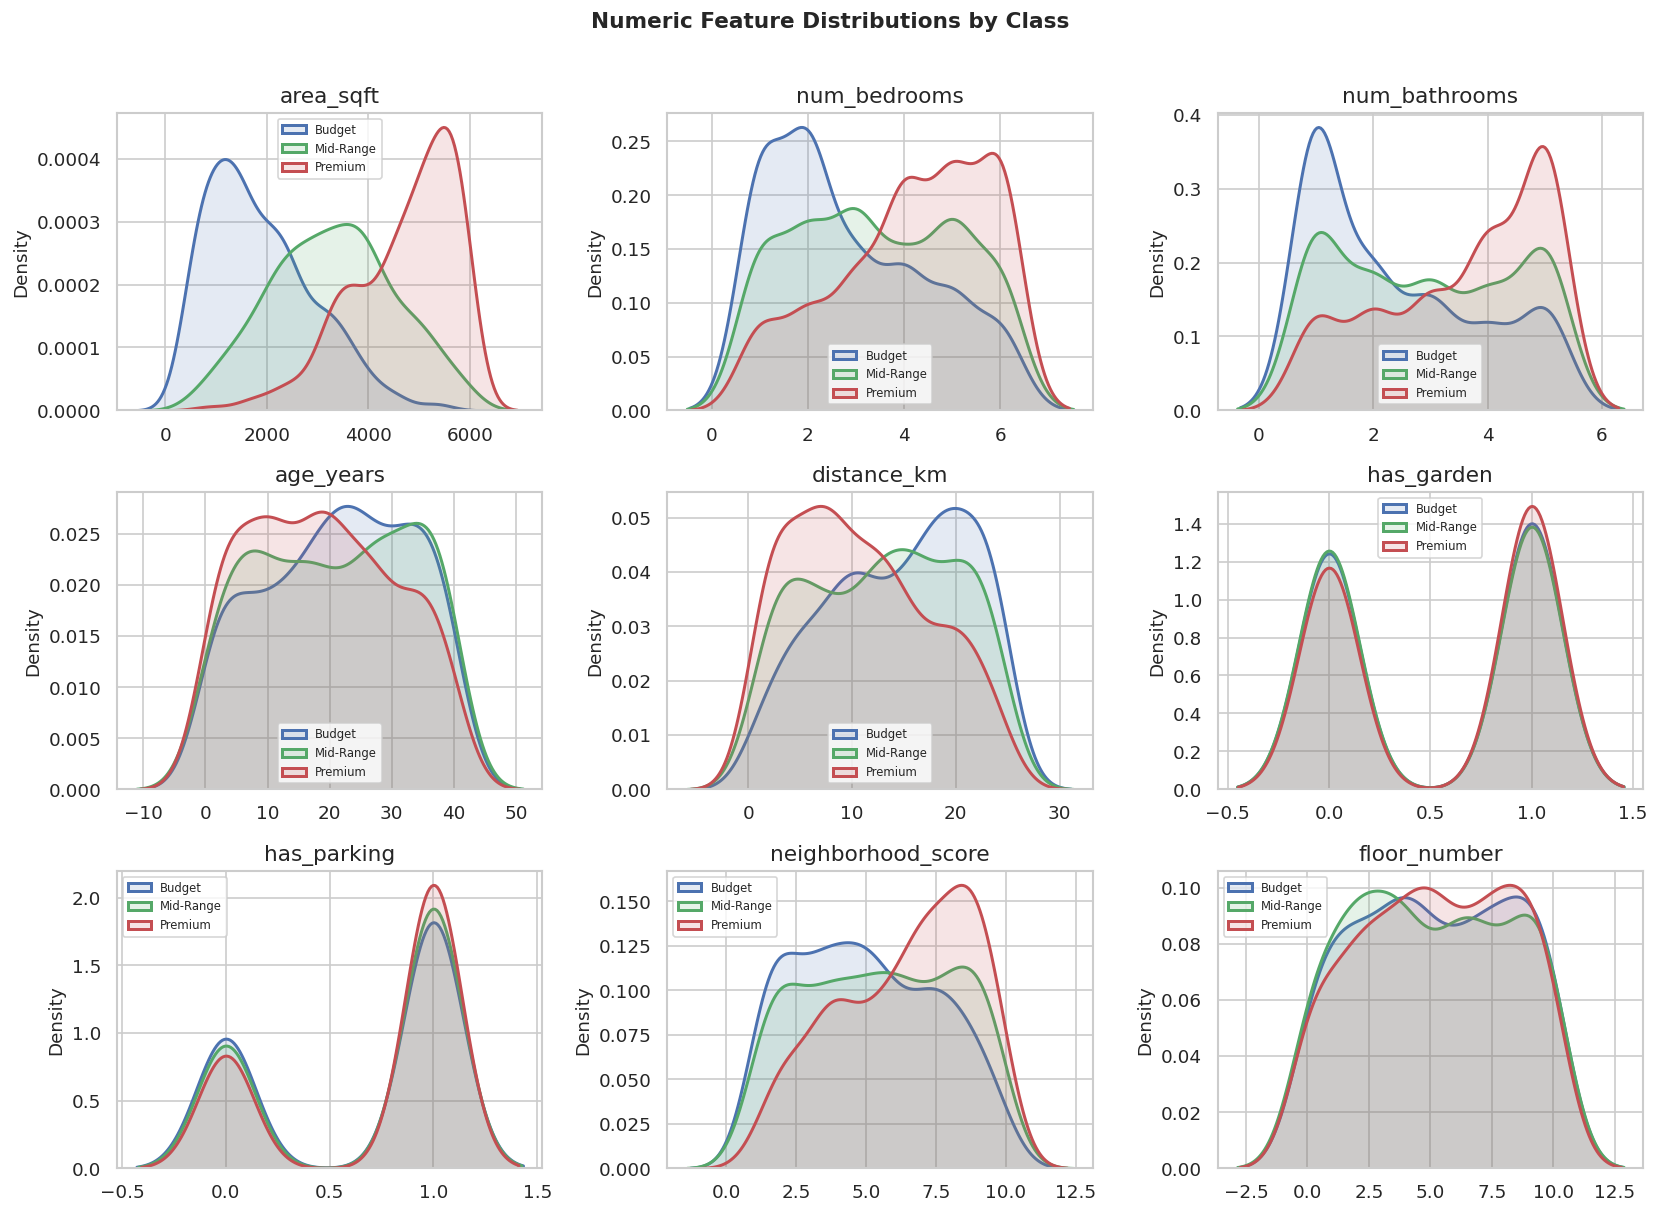

In [5]:
# Numeric feature distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, NUM_COLS):
    for cls, color in zip(range(3), CLASS_COLORS):
        sns.kdeplot(
            df[df[TARGET] == cls][col], ax=ax,
            label=CLASS_NAMES[cls], color=color,
            fill=True, alpha=0.15, linewidth=1.8
        )
    ax.set_title(col); ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.suptitle('Numeric Feature Distributions by Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_num_dist.png', bbox_inches='tight')
plt.show()

---
## Step 4: One-Hot Encoding

Machine learning models can only work with numbers. Categories like `'Urban'` or `'Villa'` need to be turned into columns of 0s and 1s. That is what One-Hot Encoding does.

For example, the `region` column becomes:

| region_Urban | region_Suburban | region_Rural |
|---|---|---|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

In [6]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Manual one-hot encoding with pandas (transparent, easy to inspect)
X_encoded = pd.get_dummies(X, columns=CAT_COLS, drop_first=False, dtype=int)

print(f'Shape BEFORE encoding: {X.shape}          ({len(NUM_COLS)} numeric + {len(CAT_COLS)} categorical)')
print(f'Shape AFTER  encoding: {X_encoded.shape}  ({X_encoded.shape[1]} total columns)')
print(f'\nNew columns added by OHE:')
new_cols = [c for c in X_encoded.columns if c not in NUM_COLS]
for c in new_cols:
    print(f'  {c}')

Shape BEFORE encoding: (1200, 12)          (9 numeric + 3 categorical)
Shape AFTER  encoding: (1200, 20)  (20 total columns)

New columns added by OHE:
  region_Rural
  region_Suburban
  region_Urban
  property_type_Apartment
  property_type_Condo
  property_type_House
  property_type_Villa
  condition_Excellent
  condition_Fair
  condition_Good
  condition_Poor


In [7]:
# Show before vs after side by side for first 5 rows
print('BEFORE encoding (categorical columns only):')
print(X[CAT_COLS].head())
print('\nAFTER encoding (OHE columns only):')
print(X_encoded[new_cols].head())

BEFORE encoding (categorical columns only):
     region property_type condition
0     Urban         Condo      Good
1     Urban         Condo      Poor
2     Urban         House      Poor
3     Urban         House      Good
4  Suburban         Villa      Fair

AFTER encoding (OHE columns only):
   region_Rural  region_Suburban  region_Urban  property_type_Apartment  \
0             0                0             1                        0   
1             0                0             1                        0   
2             0                0             1                        0   
3             0                0             1                        0   
4             0                1             0                        0   

   property_type_Condo  property_type_House  property_type_Villa  \
0                    1                    0                    0   
1                    1                    0                    0   
2                    0                    1      

---
## Step 5: Feature Scaling

Numeric columns have very different ranges — `area_sqft` goes up to 6000 while `has_garden` is just 0 or 1. Unscaled features confuse distance-based models and PCA (which is sensitive to scale).

We compare two scalers:
- **StandardScaler** — centers each column to mean 0 and std 1 (best for PCA)
- **MinMaxScaler** — squishes values between 0 and 1 (better when you need bounded output)

In [8]:
# Apply StandardScaler to the encoded feature matrix
std_scaler = StandardScaler()
X_std      = std_scaler.fit_transform(X_encoded)
X_std_df   = pd.DataFrame(X_std, columns=X_encoded.columns)

# Apply MinMaxScaler for comparison
mm_scaler = MinMaxScaler()
X_minmax  = mm_scaler.fit_transform(X_encoded)
X_minmax_df = pd.DataFrame(X_minmax, columns=X_encoded.columns)

print('StandardScaler — numeric column stats after scaling:')
print(X_std_df[NUM_COLS].agg(['mean', 'std']).round(4))

StandardScaler — numeric column stats after scaling:
      area_sqft  num_bedrooms  num_bathrooms  age_years  distance_km  \
mean     0.0000       -0.0000        -0.0000     0.0000      -0.0000   
std      1.0004        1.0004         1.0004     1.0004       1.0004   

      has_garden  has_parking  neighborhood_score  floor_number  
mean     -0.0000       0.0000             -0.0000        0.0000  
std       1.0004       1.0004              1.0004        1.0004  


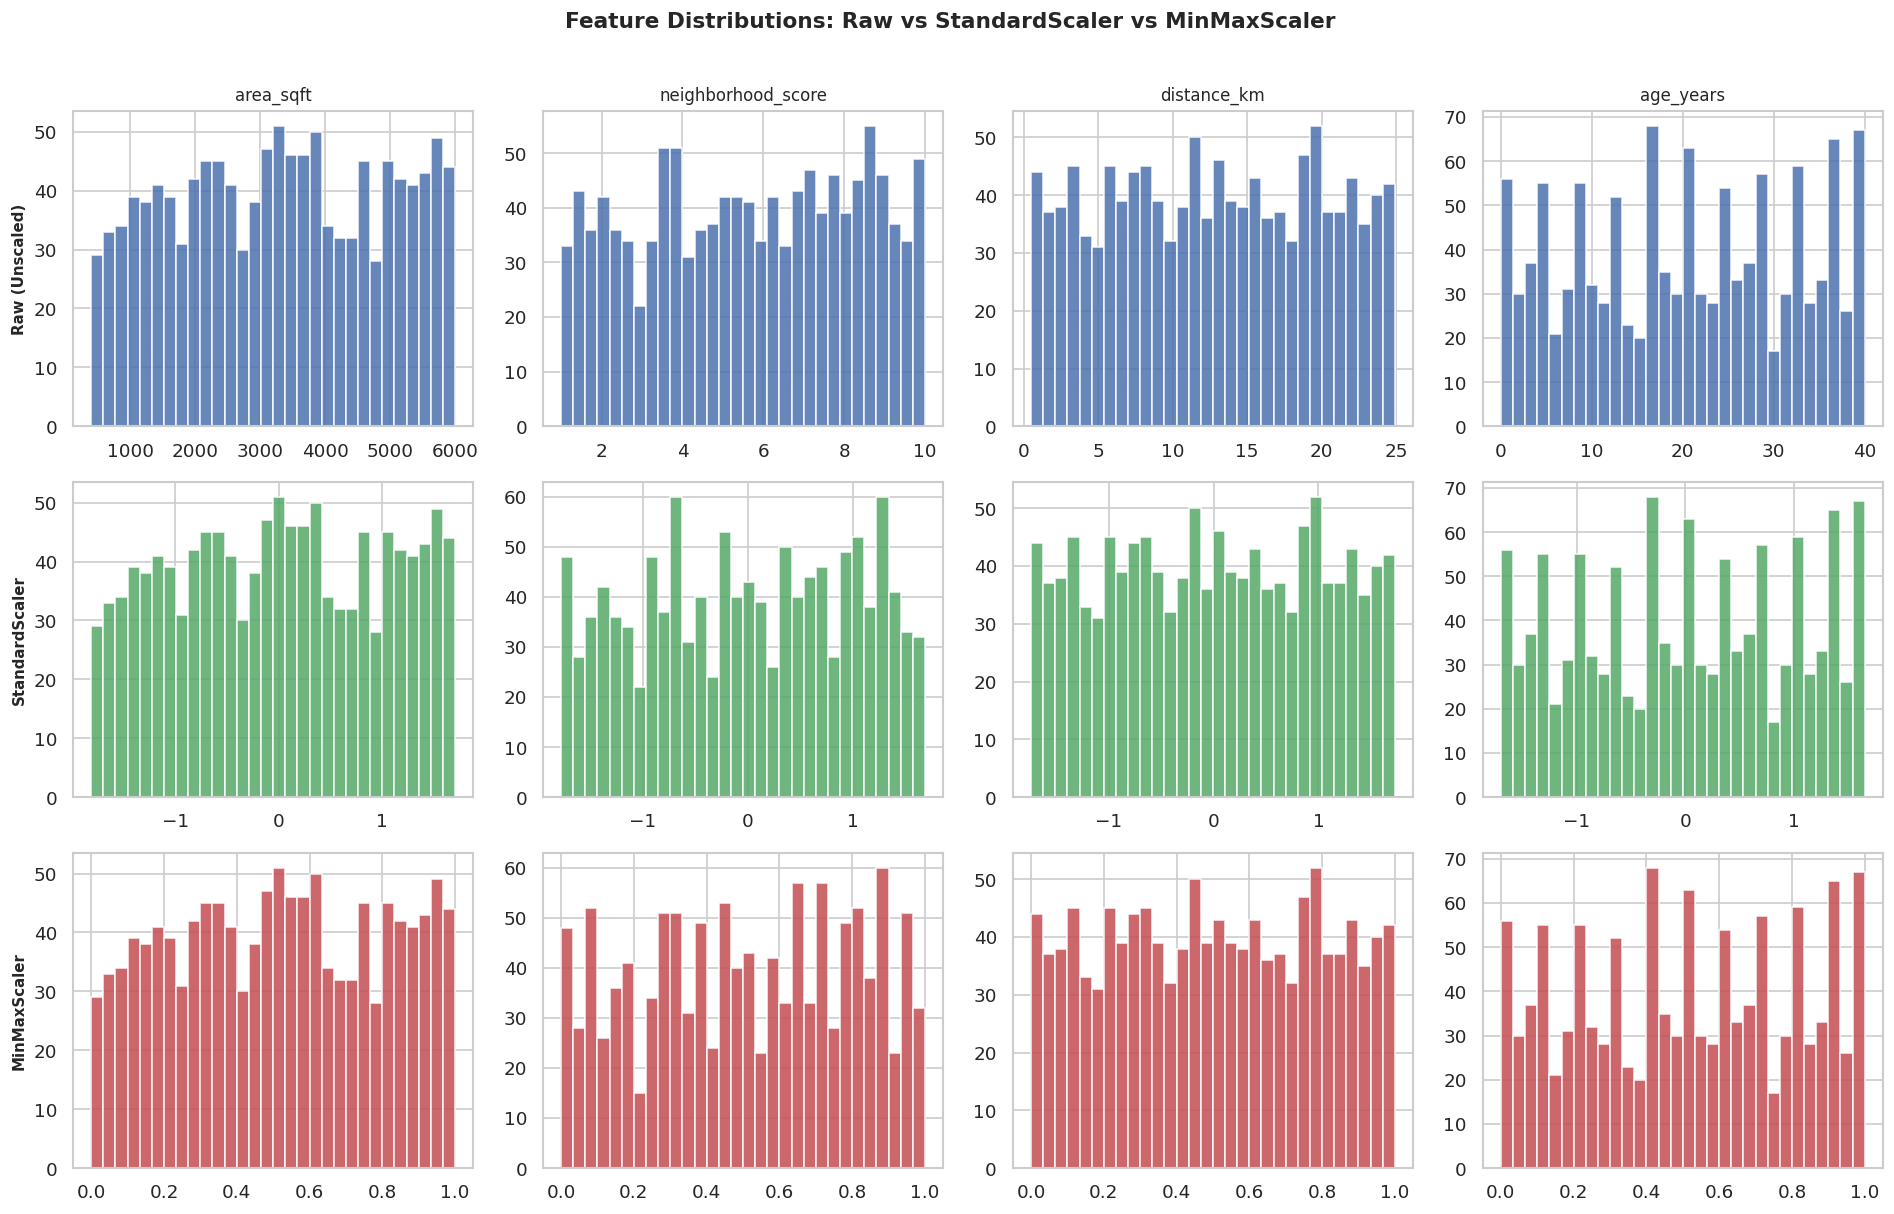

In [9]:
# Visual comparison: raw vs StandardScaler vs MinMaxScaler
compare_cols = ['area_sqft', 'neighborhood_score', 'distance_km', 'age_years']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
row_labels = ['Raw (Unscaled)', 'StandardScaler', 'MinMaxScaler']
sources    = [X[compare_cols], X_std_df[compare_cols], X_minmax_df[compare_cols]]

for row, (src, label) in enumerate(zip(sources, row_labels)):
    for col_idx, feat in enumerate(compare_cols):
        ax = axes[row][col_idx]
        ax.hist(src[feat], bins=30, color=CLASS_COLORS[row % 3], edgecolor='white', alpha=0.85)
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=9, fontweight='bold')
        if row == 0:
            ax.set_title(feat, fontsize=10)

plt.suptitle('Feature Distributions: Raw vs StandardScaler vs MinMaxScaler',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scaling_comparison.png', bbox_inches='tight')
plt.show()

---
## Step 6: Full Preprocessing Pipeline

A `Pipeline` chains steps together so they always run in the right order and there is no risk of fitting the scaler on test data.

In [10]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# ColumnTransformer applies different steps to different column groups
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),  NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
])

# Fit on train only, transform both train and test
X_train_prep = preprocessor.fit_transform(X_train_raw)
X_test_prep  = preprocessor.transform(X_test_raw)

# Recover column names for later use
ohe_cols    = preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_COLS)
all_cols    = NUM_COLS + list(ohe_cols)

X_train_df  = pd.DataFrame(X_train_prep, columns=all_cols)
X_test_df   = pd.DataFrame(X_test_prep,  columns=all_cols)

print(f'Training set shape after pipeline : {X_train_prep.shape}')
print(f'Testing  set shape after pipeline : {X_test_prep.shape}')
print(f'Total features entering PCA       : {X_train_prep.shape[1]}')
print(f'  Numeric  : {len(NUM_COLS)}')
print(f'  OHE cols : {len(ohe_cols)}')

Training set shape after pipeline : (960, 20)
Testing  set shape after pipeline : (240, 20)
Total features entering PCA       : 20
  Numeric  : 9
  OHE cols : 11


---
## Step 7: PCA — Explained Variance & Scree Plot

PCA finds new axes (called principal components) along which the data varies the most. Each component captures a percentage of the total variance. We run PCA on all components first to see how much each one contributes before deciding how many to keep.

In [11]:
# Fit full PCA (all components) on the training set
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_prep)

evr        = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)
n_features = X_train_prep.shape[1]

# Components needed for 90%, 95%, 99% variance
for threshold in [0.90, 0.95, 0.99]:
    n = np.argmax(cumulative >= threshold) + 1
    print(f'Components needed for {int(threshold*100)}% variance: {n}')

Components needed for 90% variance: 11
Components needed for 95% variance: 13
Components needed for 99% variance: 16


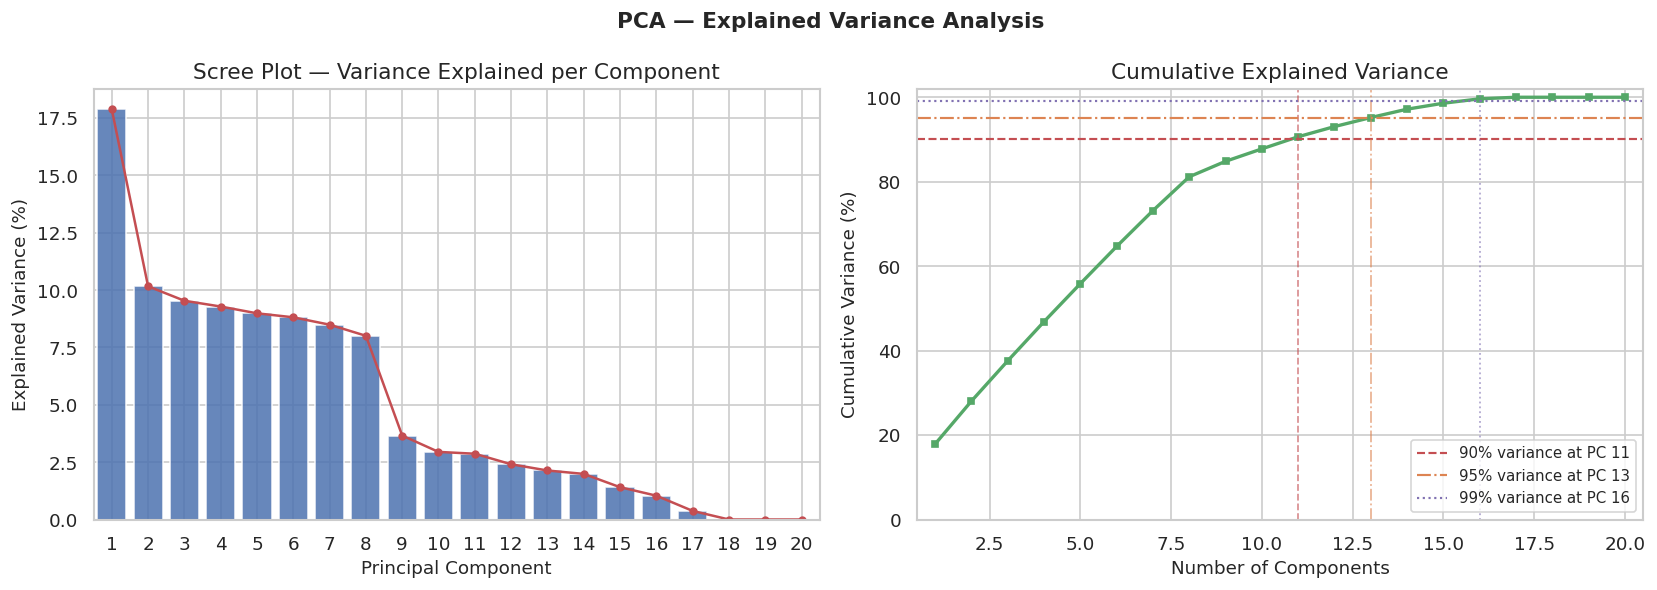

In [12]:
# Scree plot + cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Scree plot ----
x_ticks = range(1, n_features + 1)
axes[0].bar(x_ticks, evr * 100, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].plot(x_ticks, evr * 100, 'o-', color='#C44E52', markersize=4, linewidth=1.5)
axes[0].set_title('Scree Plot — Variance Explained per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_xlim(0.5, min(20, n_features) + 0.5)
axes[0].set_xticks(range(1, min(20, n_features) + 1))

# ---- Cumulative variance ----
axes[1].plot(x_ticks, cumulative * 100, 's-', color='#55A868', linewidth=2, markersize=4)
for thresh, color, ls in [(90, '#C44E52','--'), (95,'#DD8452','-.'), (99,'#8172B2',':')]:
    n = np.argmax(cumulative >= thresh/100) + 1
    axes[1].axhline(thresh,  color=color, linestyle=ls, linewidth=1.3,
                   label=f'{thresh}% variance at PC {n}')
    axes[1].axvline(n,       color=color, linestyle=ls, linewidth=1.1, alpha=0.6)

axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_xlim(0.5, n_features + 0.5)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 102)

plt.suptitle('PCA — Explained Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_variance.png', bbox_inches='tight')
plt.show()

In [13]:
# Per-component table (first 15)
variance_table = pd.DataFrame({
    'Component'        : range(1, min(16, n_features + 1)),
    'Explained Var %'  : np.round(evr[:15] * 100, 2),
    'Cumulative Var %' : np.round(cumulative[:15] * 100, 2),
})
print(variance_table.to_string(index=False))

 Component  Explained Var %  Cumulative Var %
         1            17.88             17.88
         2            10.17             28.05
         3             9.54             37.58
         4             9.28             46.87
         5             8.99             55.85
         6             8.81             64.67
         7             8.49             73.16
         8             8.01             81.17
         9             3.66             84.83
        10             2.95             87.78
        11             2.87             90.64
        12             2.41             93.05
        13             2.14             95.19
        14             1.99             97.18
        15             1.41             98.59


---
## Step 8: PCA — 2D and 3D Visualizations

We reduce our feature space down to 2 and 3 components so we can actually plot the data and see if the three property classes are separable.

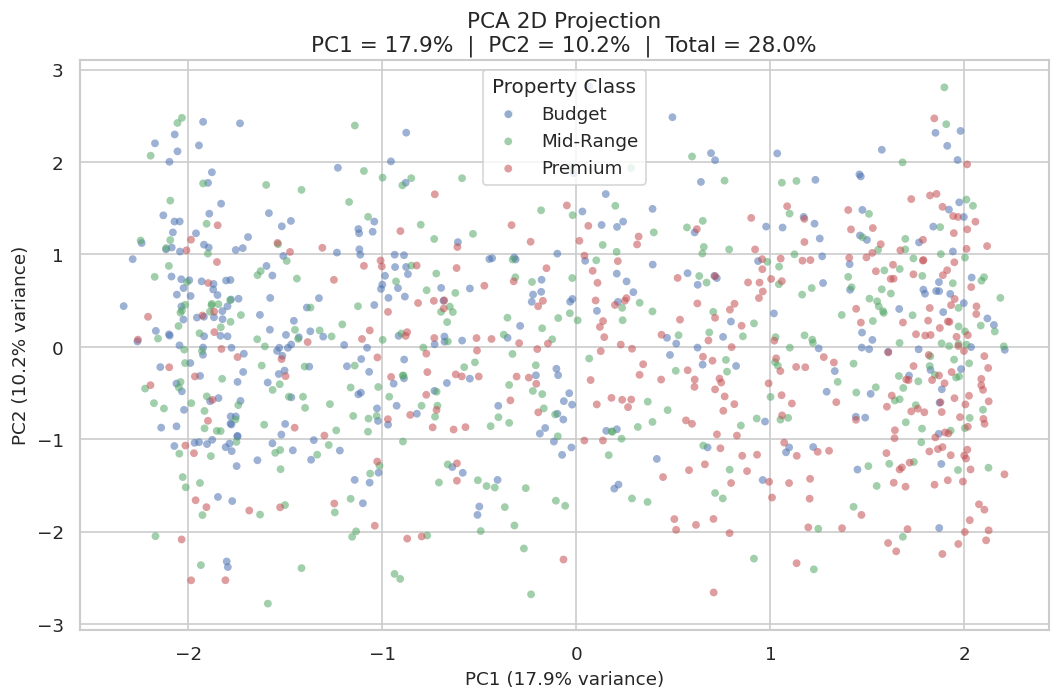

In [14]:
# 2D PCA
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_train_prep)

pca_2d_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_2d_df['Class'] = y_train.values

fig, ax = plt.subplots(figsize=(9, 6))
for cls, name, color in zip(range(3), CLASS_NAMES, CLASS_COLORS):
    subset = pca_2d_df[pca_2d_df['Class'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'],
               label=name, color=color,
               alpha=0.55, s=22, edgecolors='none')

ax.set_title(
    f'PCA 2D Projection\n'
    f'PC1 = {pca_2d.explained_variance_ratio_[0]*100:.1f}%  |  '
    f'PC2 = {pca_2d.explained_variance_ratio_[1]*100:.1f}%  |  '
    f'Total = {sum(pca_2d.explained_variance_ratio_)*100:.1f}%'
)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Property Class')
plt.tight_layout()
plt.savefig('pca_2d.png', bbox_inches='tight')
plt.show()

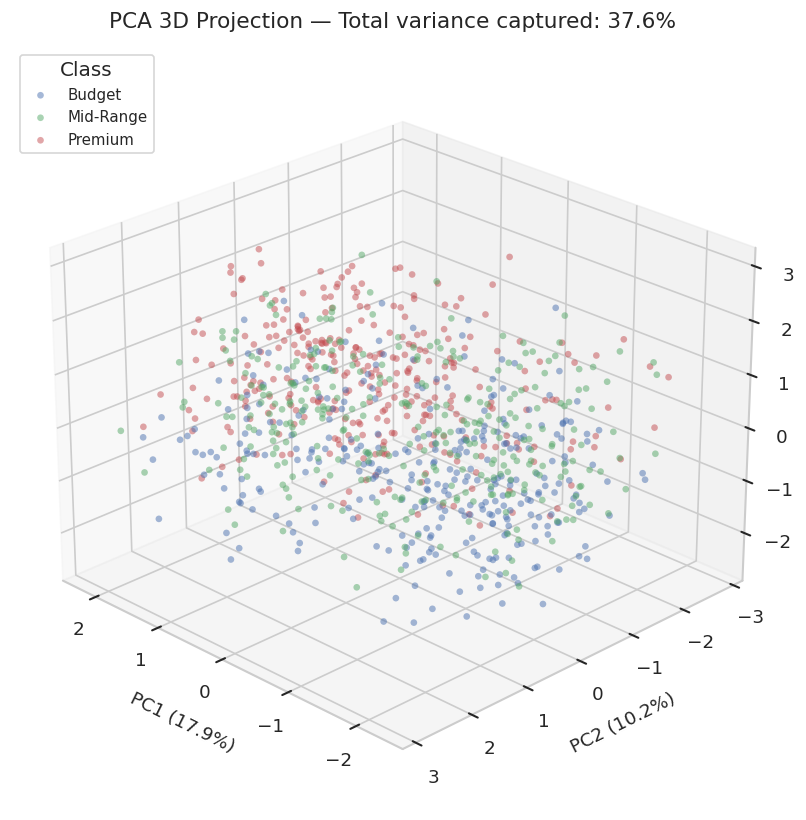

In [15]:
# 3D PCA
pca_3d = PCA(n_components=3, random_state=SEED)
X_pca_3d = pca_3d.fit_transform(X_train_prep)

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

for cls, name, color in zip(range(3), CLASS_NAMES, CLASS_COLORS):
    mask = (y_train.values == cls)
    ax.scatter(
        X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
        label=name, color=color, alpha=0.50, s=16, edgecolors='none'
    )

pct = pca_3d.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({pct[0]:.1f}%)', labelpad=8)
ax.set_ylabel(f'PC2 ({pct[1]:.1f}%)', labelpad=8)
ax.set_zlabel(f'PC3 ({pct[2]:.1f}%)', labelpad=8)
ax.set_title(
    f'PCA 3D Projection — Total variance captured: {sum(pct):.1f}%',
    pad=12
)
ax.legend(title='Class', loc='upper left', fontsize=9)
ax.view_init(elev=25, azim=135)
plt.tight_layout()
plt.savefig('pca_3d.png', bbox_inches='tight')
plt.show()

---
## Step 9: Biplot — Feature Loading Vectors

A biplot overlays the original feature directions (called loadings) onto the 2D PCA scatter. Features with long arrows in the same direction are positively correlated. Features pointing in opposite directions are negatively correlated. The arrow length shows how much a feature contributes to those two principal components.

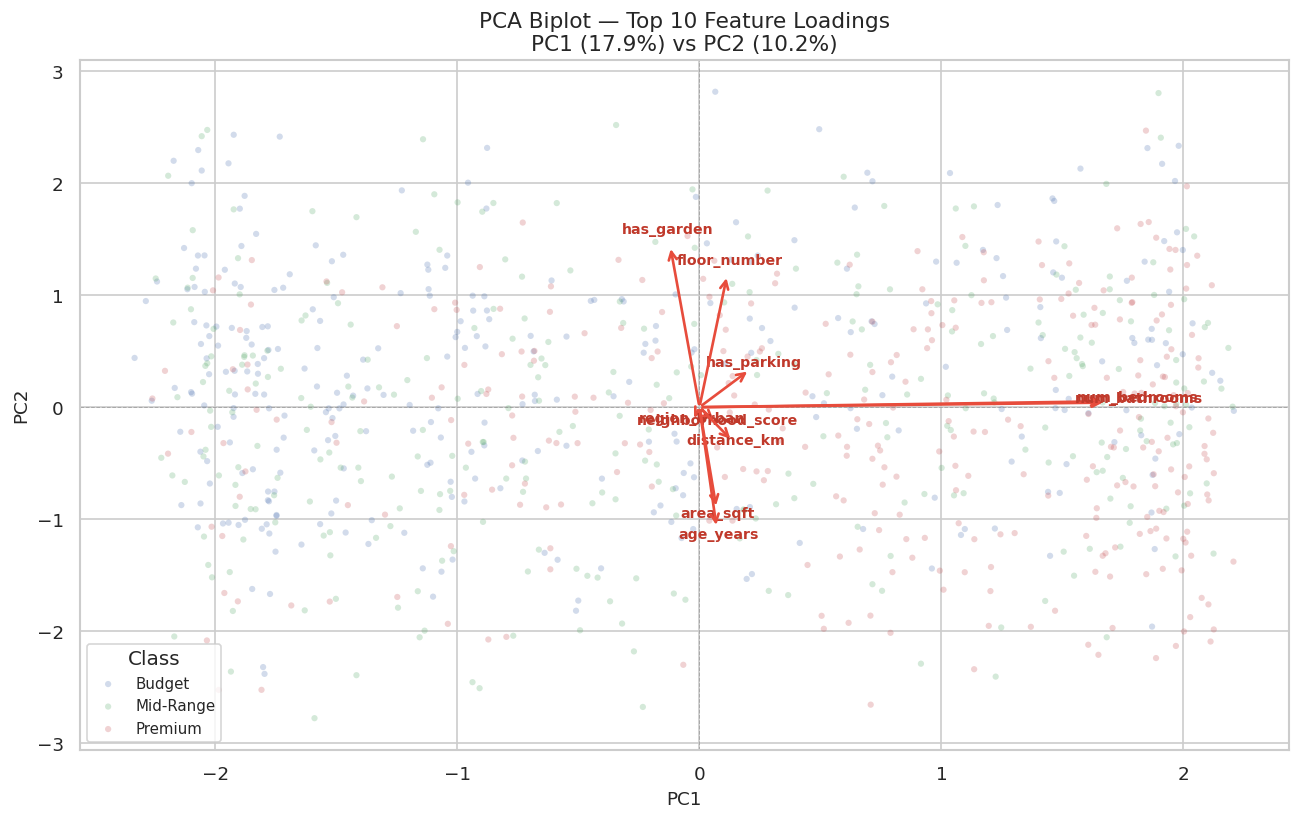

In [16]:
loadings   = pca_2d.components_.T  # shape: (n_features, 2)
scale      = np.max(np.abs(X_pca_2d)) * 0.85

# Only label the top 10 most influential features (by total loading magnitude)
magnitudes  = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_idx     = np.argsort(magnitudes)[-10:]

fig, ax = plt.subplots(figsize=(11, 7))

# Scatter (dimmed)
for cls, name, color in zip(range(3), CLASS_NAMES, CLASS_COLORS):
    subset = pca_2d_df[pca_2d_df['Class'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'],
               label=name, color=color, alpha=0.25, s=14, edgecolors='none')

# Loading arrows
for i in top_idx:
    lx, ly = loadings[i, 0] * scale, loadings[i, 1] * scale
    ax.annotate(
        '', xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.6)
    )
    ax.text(
        lx * 1.08, ly * 1.08, all_cols[i],
        fontsize=8.5, ha='center', color='#c0392b', fontweight='bold'
    )

ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_title(
    f'PCA Biplot — Top 10 Feature Loadings\n'
    f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%) vs '
    f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)'
)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(title='Class', fontsize=9)
plt.tight_layout()
plt.savefig('pca_biplot.png', bbox_inches='tight')
plt.show()

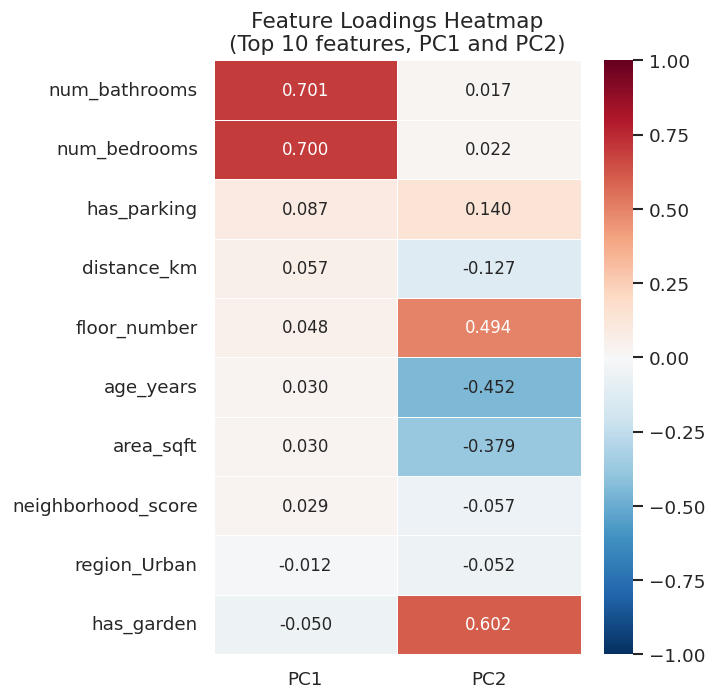

In [17]:
# Heatmap of top-10 feature loadings across PC1 and PC2
loading_df = pd.DataFrame(
    loadings[top_idx, :2],
    index=[all_cols[i] for i in top_idx],
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(
    loading_df, annot=True, fmt='.3f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 10}, ax=ax
)
ax.set_title('Feature Loadings Heatmap\n(Top 10 features, PC1 and PC2)')
plt.tight_layout()
plt.savefig('pca_loading_heatmap.png', bbox_inches='tight')
plt.show()

---
## Step 10: Choosing the Optimal Number of Components

We want the smallest number of components that still retains enough information for a classifier to work well. We sweep from 2 components to the full set and track accuracy at each step.

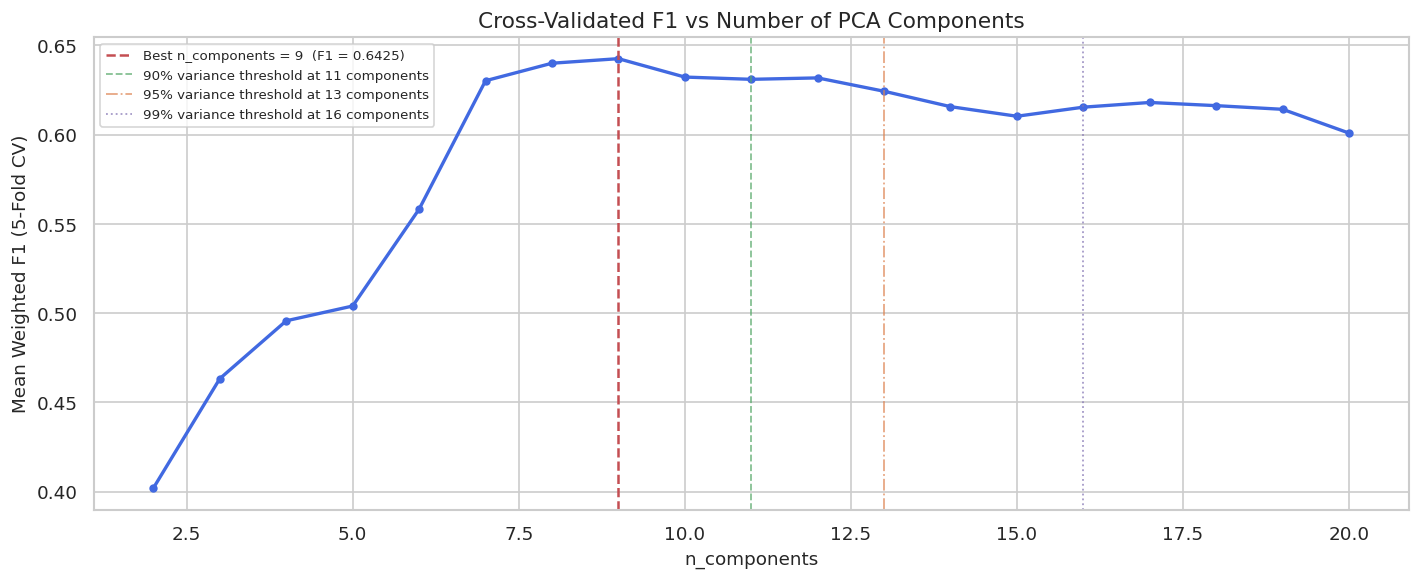

Optimal n_components: 9  |  Best CV F1: 0.6425


In [18]:
skf           = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
component_range = list(range(2, n_features + 1, 1))
cv_f1_scores  = []

for n_comp in component_range:
    pipe = Pipeline([
        ('pca', PCA(n_components=n_comp, random_state=SEED)),
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=SEED))
    ])
    scores = cross_val_score(pipe, X_train_prep, y_train, cv=skf, scoring='f1_weighted')
    cv_f1_scores.append(scores.mean())

best_n        = component_range[np.argmax(cv_f1_scores)]
best_f1       = max(cv_f1_scores)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(component_range, cv_f1_scores, 'o-', color='royalblue', linewidth=2, markersize=4)
ax.axvline(best_n, color='#C44E52', linestyle='--', linewidth=1.5,
           label=f'Best n_components = {best_n}  (F1 = {best_f1:.4f})')
for thresh, col, ls in [(0.90,'#55A868','--'), (0.95,'#DD8452','-.'), (0.99,'#8172B2',':')]:
    n_at = np.argmax(cumulative >= thresh) + 1
    ax.axvline(n_at, color=col, linestyle=ls, linewidth=1.1, alpha=0.7,
               label=f'{int(thresh*100)}% variance threshold at {n_at} components')

ax.set_title('Cross-Validated F1 vs Number of PCA Components')
ax.set_xlabel('n_components')
ax.set_ylabel('Mean Weighted F1 (5-Fold CV)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('pca_n_components_search.png', bbox_inches='tight')
plt.show()
print(f'Optimal n_components: {best_n}  |  Best CV F1: {best_f1:.4f}')

In [19]:
# Final PCA transform with optimal components
pca_opt        = PCA(n_components=best_n, random_state=SEED)
X_train_pca    = pca_opt.fit_transform(X_train_prep)
X_test_pca     = pca_opt.transform(X_test_prep)

variance_kept  = pca_opt.explained_variance_ratio_.sum() * 100
reduction_pct  = (1 - best_n / n_features) * 100

print(f'Original features  : {n_features}')
print(f'PCA components kept: {best_n}')
print(f'Dimensionality reduction: {reduction_pct:.1f}%')
print(f'Variance retained        : {variance_kept:.2f}%')

Original features  : 20
PCA components kept: 9
Dimensionality reduction: 55.0%
Variance retained        : 84.83%


---
## Step 11: Before vs After PCA — Classifier Comparison

We train a Decision Tree on the raw preprocessed features and again on the PCA-reduced features, then compare accuracy, F1 score, and training speed.

In [20]:
import time

dt = DecisionTreeClassifier(max_depth=8, random_state=SEED)

# Without PCA
t0 = time.time()
dt.fit(X_train_prep, y_train)
t_no_pca     = (time.time() - t0) * 1000
y_pred_nopca = dt.predict(X_test_prep)
acc_nopca    = accuracy_score(y_test, y_pred_nopca)
f1_nopca     = f1_score(y_test, y_pred_nopca, average='weighted')

# With PCA
t0 = time.time()
dt.fit(X_train_pca, y_train)
t_pca        = (time.time() - t0) * 1000
y_pred_pca   = dt.predict(X_test_pca)
acc_pca      = accuracy_score(y_test, y_pred_pca)
f1_pca       = f1_score(y_test, y_pred_pca, average='weighted')

print('='*60)
print('       WITHOUT PCA          |      WITH PCA')
print('='*60)
print(f'  Features   : {n_features:<10}         |  {best_n}')
print(f'  Accuracy   : {acc_nopca:.4f}            |  {acc_pca:.4f}')
print(f'  W. F1      : {f1_nopca:.4f}            |  {f1_pca:.4f}')
print(f'  Train time : {t_no_pca:.2f} ms           |  {t_pca:.2f} ms')
print(f'  Var kept   : 100%                |  {variance_kept:.1f}%')
print('='*60)

       WITHOUT PCA          |      WITH PCA
  Features   : 20                 |  9
  Accuracy   : 0.6583            |  0.5875
  W. F1      : 0.6661            |  0.5917
  Train time : 10.21 ms           |  15.35 ms
  Var kept   : 100%                |  84.8%


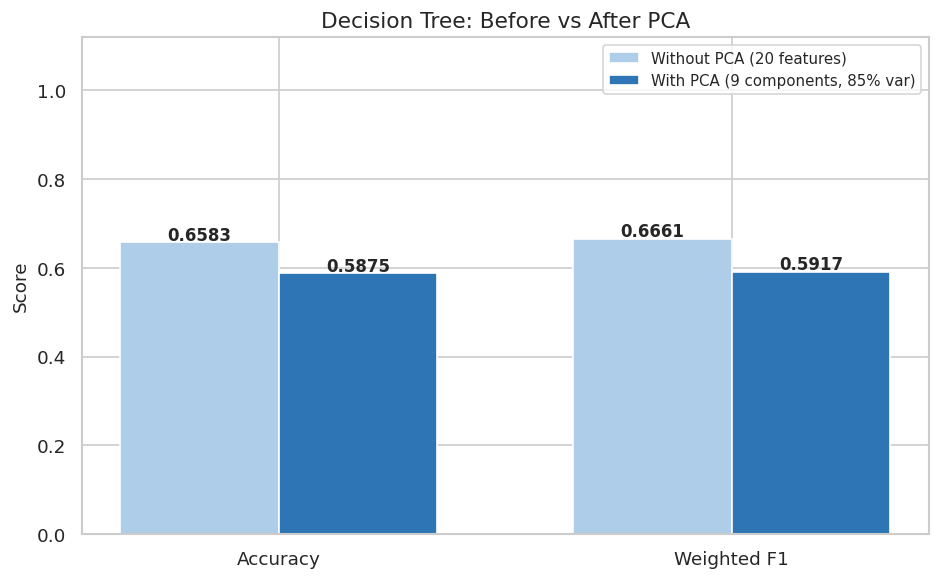

In [21]:
# Visual comparison bar chart
labels   = ['Accuracy', 'Weighted F1']
no_pca_v = [acc_nopca, f1_nopca]
pca_v    = [acc_pca,    f1_pca]
x        = np.arange(len(labels))
w        = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, no_pca_v, w, label=f'Without PCA ({n_features} features)',
            color='#AECDE8', edgecolor='white')
b2 = ax.bar(x + w/2, pca_v,    w, label=f'With PCA ({best_n} components, {variance_kept:.0f}% var)',
            color='#2E75B6', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Decision Tree: Before vs After PCA')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('before_vs_after_pca.png', bbox_inches='tight')
plt.show()

---
## Step 12: Summary

In [22]:
summary = pd.DataFrame([
    {'Stage': 'Raw dataset',
     'Features': f'{len(NUM_COLS)} numeric + {len(CAT_COLS)} categorical',
     'Columns': X.shape[1], 'Note': 'Original input'},
    {'Stage': 'After OHE',
     'Features': f'{len(NUM_COLS)} numeric + {len(ohe_cols)} OHE',
     'Columns': n_features, 'Note': 'Categories expanded'},
    {'Stage': 'After StandardScaler',
     'Features': f'{n_features} scaled',
     'Columns': n_features, 'Note': 'Mean=0, Std=1'},
    {'Stage': f'After PCA (n={best_n})',
     'Features': f'{best_n} components',
     'Columns': best_n, 'Note': f'{variance_kept:.1f}% variance kept, {reduction_pct:.0f}% reduction'},
])
print(summary.to_string(index=False))

print(f"""
FEATURE ENGINEERING RECAP

  One-Hot Encoding   : 3 categorical cols expanded to {len(ohe_cols)} binary cols
  StandardScaler     : All {n_features} features scaled to mean=0, std=1
  PCA                : {n_features} features reduced to {best_n} components
  Variance retained  : {variance_kept:.2f}%
  Dimensionality cut : {reduction_pct:.0f}%

  Classifier F1 without PCA : {f1_nopca:.4f}
  Classifier F1 with PCA    : {f1_pca:.4f}
  Difference                : {abs(f1_pca - f1_nopca):.4f}  (PCA trades a tiny bit of
                                accuracy for a much smaller feature space)
""")

               Stage                  Features  Columns                               Note
         Raw dataset 9 numeric + 3 categorical       12                     Original input
           After OHE        9 numeric + 11 OHE       20                Categories expanded
After StandardScaler                 20 scaled       20                      Mean=0, Std=1
     After PCA (n=9)              9 components        9 84.8% variance kept, 55% reduction

FEATURE ENGINEERING RECAP

  One-Hot Encoding   : 3 categorical cols expanded to 11 binary cols
  StandardScaler     : All 20 features scaled to mean=0, std=1
  PCA                : 20 features reduced to 9 components
  Variance retained  : 84.83%
  Dimensionality cut : 55%

  Classifier F1 without PCA : 0.6661
  Classifier F1 with PCA    : 0.5917
  Difference                : 0.0744  (PCA trades a tiny bit of
                                accuracy for a much smaller feature space)



---
## Quick Reference — What Each Step Does

| Technique | What it does | When to use |
|---|---|---|
| **One-Hot Encoding** | Converts text categories into 0/1 columns | Any categorical column with no natural order |
| **StandardScaler** | Centers each column at 0 with std = 1 | Before PCA, SVM, KNN, neural nets |
| **MinMaxScaler** | Squishes values between 0 and 1 | When you need bounded output |
| **PCA** | Rotates and compresses features into fewer components | When features are many or correlated |
| **Scree plot** | Shows how much variance each component explains | Choosing how many components to keep |
| **Biplot** | Shows which original features drive each PC axis | Understanding what PCA actually learned |
| **ColumnTransformer** | Applies different steps to different column types | Combining OHE and scaling cleanly |
| **Pipeline** | Chains steps to prevent data leakage | Any multi-step preprocessing flow |